# 07 - Training load and inferred physiology

This notebook uses prepared training data and heart-rate fields from the Apple Watch export to estimate training load, HR zones, change over time, and physiology-style patterns.


## Read this first

These are inferred training metrics, not clinical measurements. Heart-rate zones and LTHR proxies depend on assumptions. The goal is to make those assumptions clear enough to inspect and improve.

Useful interpretation rule:

$$
\text{observed HR pattern} \ne \text{medical diagnosis}
$$

Code-style implementation:

```python
# Treat physiology metrics as training estimates, not lab measurements.
```

This notebook uses workout-level HR summaries (`avg_hr`, `max_hr`, `min_hr`, `hr90_s`) rather than expanding every raw HR sample. That keeps it fast and makes it easier to learn from.


## 1) Imports and project paths

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [ ]:
from pathlib import Path
import json
import math
import warnings
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_EXPORT_PATH = RAW_DATA_DIR / "go-swim-export.json"

prepared_workouts_path = PROCESSED_DIR / "workouts.json"
clean_workouts_path = PROCESSED_DIR / "clean_workouts.csv"

if not prepared_workouts_path.exists():
    raise FileNotFoundError("Run scripts/build_analysis.py first so data/processed/workouts.json exists.")

print("Project root:", ROOT)
print("Prepared workout summaries:", prepared_workouts_path)


## 2) Load heart-rate enriched workout summaries

The project parser already turns the raw workout export into one row per workout with heart-rate summaries.

Data flow:

$$
\text{raw workout export} \rightarrow \text{workout HR summary rows} \rightarrow \text{physiology metrics}
$$

Code-style implementation:

```python
workouts = pd.read_json(PROCESSED_DIR / "workouts.json")
```

**Expected output:** Expect the raw JSON data to load successfully. Use any preview or counts to confirm the file structure matches what later cleaning steps expect.


In [ ]:
workouts = pd.read_json(prepared_workouts_path)
workouts["date"] = pd.to_datetime(workouts["date"], errors="coerce")
workouts["start"] = pd.to_datetime(workouts["start"], errors="coerce")
workouts["week_start"] = workouts["date"].dt.to_period("W").dt.start_time

numeric_cols = [
    "distance_m", "distance_km", "duration_s", "duration_min", "swim_time_s", "swim_time_min",
    "rest_time_s", "rest_time_min", "pace_50_s", "avg_hr", "max_hr", "min_hr", "hr90_s",
    "hr90_min", "hr90_ratio", "simple_hr_load", "heart_rate_samples"
]
for col in numeric_cols:
    if col in workouts.columns:
        workouts[col] = pd.to_numeric(workouts[col], errors="coerce")

workouts = workouts.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
print("Workout rows:", len(workouts))
display(workouts[["date", "distance_m", "duration_min", "avg_hr", "max_hr", "min_hr", "hr90_min", "pace_50_s"]].head(3))
display(workouts[["date", "distance_m", "duration_min", "avg_hr", "max_hr", "min_hr", "hr90_min", "pace_50_s"]].tail(3))


Workout rows: 483


,date,distance_m,duration_min,avg_hr,max_hr,min_hr,hr90_min,pace_50_s
0,2024-05-31,2857.500076,127.473804,138.263706,185.0,89.0,14.199936,44.170471
1,2024-06-01,1828.800049,143.312278,143.804071,195.0,99.0,12.783258,96.275132
2,2024-06-03,3520.440094,127.922737,144.703704,191.0,71.0,35.633446,48.889948


,date,distance_m,duration_min,avg_hr,max_hr,min_hr,hr90_min,pace_50_s
480,2026-06-16,2788.920074,125.811543,141.635606,188.0,85.0,8.283333,48.407781
481,2026-06-16,4400.000000,156.098033,144.900585,183.0,83.0,34.133321,68.881173
482,2026-06-17,5300.000000,144.402625,131.661352,173.0,74.0,15.166667,47.979565


## 3) Infer physiology anchors

We need HR anchors before estimating zones. Because this comes from workout data, the low value is an active low proxy, not true resting HR.

Observed max heart rate:

$$
HR_{max,obs} = \max(HR_{max,workout})
$$

Code-style implementation:

```python
observed_hr_max = workouts["max_hr"].max()
```

Active low heart-rate proxy:

$$
HR_{low,active} = P_5(HR_{min,workout})
$$

Code-style implementation:

```python
active_low_hr = workouts["min_hr"].quantile(0.05)
```

LTHR proxy from sustained workout averages:

$$
LTHR_{proxy} = P_{90}(HR_{avg,workouts \ge 20min})
$$

Code-style implementation:

```python
lthr_proxy = long_workouts["avg_hr"].quantile(0.90)
```

This estimates a high sustainable training HR from existing workout data. It is not a lab-tested lactate threshold.

**Expected output:** Expect heart-rate-derived metrics or zones. Treat these as useful training proxies, not medical or laboratory measurements.


In [ ]:
observed_hr_max = workouts["max_hr"].max()
active_low_hr = workouts["min_hr"].quantile(0.05)
long_workouts = workouts[workouts["duration_min"] >= 20].copy()
lthr_proxy = long_workouts["avg_hr"].quantile(0.90)

hr_anchors = pd.DataFrame([
    {"metric": "observed_hr_max", "value": observed_hr_max},
    {"metric": "active_low_hr_proxy", "value": active_low_hr},
    {"metric": "lthr_proxy_from_avg_hr_p90", "value": lthr_proxy},
])
hr_anchors


,metric,value
0,observed_hr_max,208.000000
1,active_low_hr_proxy,67.000000
2,lthr_proxy_from_avg_hr_p90,152.853372


## 4) Add age-aware and alternate HR zone interpretations

The athlete's date of birth is `XXXX-XX-XX`, so the workout dataset crosses ages 15 to 17. The max-HR difference across this window is small, but it is still real enough to document.

There is not one perfect HR zone system. The American Heart Association describes age-predicted max HR as a general guide, using about `220 - age`, and gives broad target ranges as percentages of maximum HR. Karvonen-style HR reserve uses the distance between low/resting HR and max HR. Lactate-threshold-style zones use a threshold anchor instead of max HR.

References used for context:

- American Heart Association target HR guidance: https://www.heart.org/en/healthy-living/exercise-and-physical-activity/fitness-basics/target-heart-rates
- Karvonen / HR reserve concept: https://en.wikipedia.org/wiki/Heart_rate#Karvonen_method
- Lactate threshold concept: https://en.wikipedia.org/wiki/Lactate_threshold

Age in years:

$$
age = \frac{workout\ date - DOB}{365.2425}
$$

Age-predicted max HR examples:

$$
HR_{max,Fox} = 220 - age
$$

$$
HR_{max,Tanaka} = 208 - 0.7 \times age
$$

LTHR ratio:

$$
R_{LTHR} = \frac{HR_{avg}}{LTHR_{proxy}}
$$

**Expected output:** Expect a compact comparison of age range, age-predicted max HR range, and several zone systems. The student should notice that the methods classify effort differently because they use different anchors.


In [ ]:
ATHLETE_DOB = pd.Timestamp("2009-01-01")
workout_date_for_age = pd.to_datetime(workouts["date"], utc=True).dt.tz_localize(None)
workouts["athlete_age_years"] = (workout_date_for_age - ATHLETE_DOB).dt.days / 365.25

# Age-predicted max HR estimates. These are general formulas, not athlete-specific tests.
workouts["age_pred_hr_max_fox"] = 220 - workouts["athlete_age_years"]
workouts["age_pred_hr_max_tanaka"] = 208 - (0.7 * workouts["athlete_age_years"])

age_hr_context = pd.DataFrame([
    {"metric": "athlete_dob", "value": "2009-01-01", "interpretation": "Known birth date used to compute workout age."},
    {"metric": "min_workout_age_years", "value": round(workouts["athlete_age_years"].min(), 2), "interpretation": "Youngest age represented in the workout file."},
    {"metric": "max_workout_age_years", "value": round(workouts["athlete_age_years"].max(), 2), "interpretation": "Oldest age represented in the workout file."},
    {"metric": "observed_hr_max", "value": round(observed_hr_max, 1), "interpretation": "Highest HR seen in workout summaries."},
    {"metric": "age_pred_hr_max_fox_min", "value": round(workouts["age_pred_hr_max_fox"].min(), 1), "interpretation": "Lowest 220-age estimate across the data window."},
    {"metric": "age_pred_hr_max_fox_max", "value": round(workouts["age_pred_hr_max_fox"].max(), 1), "interpretation": "Highest 220-age estimate across the data window."},
    {"metric": "age_pred_hr_max_tanaka_min", "value": round(workouts["age_pred_hr_max_tanaka"].min(), 1), "interpretation": "Lowest 208 - 0.7*age estimate across the data window."},
    {"metric": "age_pred_hr_max_tanaka_max", "value": round(workouts["age_pred_hr_max_tanaka"].max(), 1), "interpretation": "Highest 208 - 0.7*age estimate across the data window."},
])

age_hr_context


### 4a) Compare zone systems

These zone systems answer slightly different questions:

| Method | Anchor | What it helps compare |
|---|---|---|
| Percent of observed max HR | observed max HR in this dataset | How close a workout was to the highest HR actually seen. |
| Percent of age-predicted max HR | estimated max HR for age on that workout date | How the zone changes slightly as the athlete ages. |
| HR reserve / Karvonen-style | active low HR proxy to age-predicted max HR | How hard the workout was relative to the athlete's estimated usable HR range. |
| LTHR-proxy ratio | inferred threshold-like HR | Whether average HR was below, near, or above the inferred threshold proxy. |

For this project, the LTHR version is especially interesting because it uses the athlete's own training data instead of only a general age formula.

**Expected output:** Expect side-by-side zone labels for the same workouts. If the labels disagree, that is not automatically an error; it shows that different formulas frame intensity differently.


In [ ]:
max_zone_bins = [-np.inf, 0.60, 0.70, 0.80, 0.90, np.inf]
max_zone_labels = ["z1_under_60", "z2_60_70", "z3_70_80", "z4_80_90", "z5_90_plus"]

lthr_zone_bins = [-np.inf, 0.85, 0.90, 0.95, 1.00, 1.06, np.inf]
lthr_zone_labels = ["lthr_z1_under_85", "lthr_z2_85_90", "lthr_z3_90_95", "lthr_z4_95_100", "lthr_z5_100_106", "lthr_z6_106_plus"]

workouts["avg_pct_observed_max"] = workouts["avg_hr"] / observed_hr_max
workouts["avg_pct_age_max_fox"] = workouts["avg_hr"] / workouts["age_pred_hr_max_fox"]
workouts["avg_pct_age_max_tanaka"] = workouts["avg_hr"] / workouts["age_pred_hr_max_tanaka"]
workouts["avg_hrr_intensity_age_fox"] = (workouts["avg_hr"] - active_low_hr) / (workouts["age_pred_hr_max_fox"] - active_low_hr)
workouts["avg_lthr_ratio"] = workouts["avg_hr"] / lthr_proxy

workouts["zone_pct_observed_max"] = pd.cut(workouts["avg_pct_observed_max"], bins=max_zone_bins, labels=max_zone_labels)
workouts["zone_pct_age_max_fox"] = pd.cut(workouts["avg_pct_age_max_fox"], bins=max_zone_bins, labels=max_zone_labels)
workouts["zone_pct_age_max_tanaka"] = pd.cut(workouts["avg_pct_age_max_tanaka"], bins=max_zone_bins, labels=max_zone_labels)
workouts["zone_hrr_age_fox"] = pd.cut(workouts["avg_hrr_intensity_age_fox"], bins=max_zone_bins, labels=max_zone_labels)
workouts["zone_lthr_proxy"] = pd.cut(workouts["avg_lthr_ratio"], bins=lthr_zone_bins, labels=lthr_zone_labels)

hr_zone_method_summary = pd.DataFrame([
    {
        "method": "percent_observed_max",
        "anchor": "observed_hr_max from workouts",
        "formula": "avg_hr / observed_hr_max",
        "best_use": "Compares workouts to the highest HR actually seen in this dataset.",
        "main_caution": "Observed max may be lower than true max HR, or one unusual value may set the anchor.",
    },
    {
        "method": "percent_age_predicted_max_fox",
        "anchor": "220 - workout_age",
        "formula": "avg_hr / (220 - age)",
        "best_use": "Shows how a common age-based max-HR zone shifts as the athlete ages.",
        "main_caution": "Age formulas are broad averages and can be off for an individual athlete.",
    },
    {
        "method": "percent_age_predicted_max_tanaka",
        "anchor": "208 - 0.7 * workout_age",
        "formula": "avg_hr / (208 - 0.7*age)",
        "best_use": "Gives a second age-based comparison formula for sensitivity checking.",
        "main_caution": "Still a general estimate, not a measured max HR test.",
    },
    {
        "method": "age_adjusted_hrr",
        "anchor": "active low HR proxy to age-predicted max HR",
        "formula": "(avg_hr - active_low_hr) / ((220 - age) - active_low_hr)",
        "best_use": "Compares effort relative to an estimated usable HR range.",
        "main_caution": "Uses active low HR, not true resting HR, so this is a project proxy.",
    },
    {
        "method": "lthr_proxy_ratio",
        "anchor": "inferred LTHR proxy from workout data",
        "formula": "avg_hr / lthr_proxy",
        "best_use": "Compares workouts against an athlete-specific threshold-like estimate.",
        "main_caution": "The threshold is inferred from data, not measured by blood lactate or lab testing.",
    },
])

hr_zone_interpretations = workouts[[
    "date",
    "athlete_age_years",
    "avg_hr",
    "max_hr",
    "age_pred_hr_max_fox",
    "age_pred_hr_max_tanaka",
    "avg_pct_observed_max",
    "avg_pct_age_max_fox",
    "avg_pct_age_max_tanaka",
    "avg_hrr_intensity_age_fox",
    "avg_lthr_ratio",
    "zone_pct_observed_max",
    "zone_pct_age_max_fox",
    "zone_pct_age_max_tanaka",
    "zone_hrr_age_fox",
    "zone_lthr_proxy",
]].copy()

display(hr_zone_method_summary)
display(hr_zone_interpretations.head(3))
display(hr_zone_interpretations.tail(3))


,method,anchor,formula,best_use,main_caution
0,percent_observed_max,observed_hr_max from workouts,avg_hr / observed_hr_max,Compares workouts to the highest HR actually s...,"Observed max may be lower than true max HR, or..."
1,percent_age_predicted_max_fox,220 - workout_age,avg_hr / (220 - age),Shows how a common age-based max-HR zone shift...,Age formulas are broad averages and can be off...
2,percent_age_predicted_max_tanaka,208 - 0.7 * workout_age,avg_hr / (208 - 0.7*age),Gives a second age-based comparison formula fo...,"Still a general estimate, not a measured max H..."
3,age_adjusted_hrr,active low HR proxy to age-predicted max HR,(avg_hr - active_low_hr) / ((220 - age) - acti...,Compares effort relative to an estimated usabl...,"Uses active low HR, not true resting HR, so th..."
4,lthr_proxy_ratio,inferred LTHR proxy from workout data,avg_hr / lthr_proxy,Compares workouts against an athlete-specific ...,"The threshold is inferred from data, not measu..."


,date,athlete_age_years,avg_hr,max_hr,age_pred_hr_max_fox,age_pred_hr_max_tanaka,avg_pct_observed_max,avg_pct_age_max_fox,avg_pct_age_max_tanaka,avg_hrr_intensity_age_fox,avg_lthr_ratio,zone_pct_observed_max,zone_pct_age_max_fox,zone_pct_age_max_tanaka,zone_hrr_age_fox,zone_lthr_proxy
0,2024-05-31,15.000992,138.263706,185.0,204.999008,197.499305,0.664729,0.674460,0.700072,0.516407,0.904551,z2_60_70,z2_60_70,z3_70_80,z1_under_60,lthr_z3_90_95
1,2024-06-01,15.003730,143.804071,195.0,204.996270,197.497389,0.691366,0.701496,0.728132,0.556566,0.940798,z2_60_70,z3_70_80,z3_70_80,z1_under_60,lthr_z3_90_95
2,2024-06-03,15.009206,144.703704,191.0,204.990794,197.493556,0.695691,0.705903,0.732701,0.563108,0.946683,z2_60_70,z3_70_80,z3_70_80,z1_under_60,lthr_z3_90_95


,date,athlete_age_years,avg_hr,max_hr,age_pred_hr_max_fox,age_pred_hr_max_tanaka,avg_pct_observed_max,avg_pct_age_max_fox,avg_pct_age_max_tanaka,avg_hrr_intensity_age_fox,avg_lthr_ratio,zone_pct_observed_max,zone_pct_age_max_fox,zone_pct_age_max_tanaka,zone_hrr_age_fox,zone_lthr_proxy
480,2026-06-16,17.043471,141.635606,188.0,202.956529,196.069570,0.680940,0.697862,0.722374,0.548967,0.926611,z2_60_70,z2_60_70,z3_70_80,z1_under_60,lthr_z3_90_95
481,2026-06-16,17.043471,144.900585,183.0,202.956529,196.069570,0.696637,0.713949,0.739026,0.572982,0.947971,z2_60_70,z3_70_80,z3_70_80,z1_under_60,lthr_z3_90_95
482,2026-06-17,17.046209,131.661352,173.0,202.953791,196.067654,0.632987,0.648726,0.671510,0.475613,0.861357,z2_60_70,z2_60_70,z2_60_70,z1_under_60,lthr_z2_85_90


### 4b) Build sample-based zone depth

A workout average HR can hide the real shape of a swim. For example, warmup, threshold sets, rest intervals, and cooldown can average into `z1` even when the workout included meaningful higher-zone work.

Instead of only asking "what zone was the average HR?", this step asks:

$$
\text{zone minutes}_z = \sum \text{seconds where HR sample is in zone } z \div 60
$$

Weighted zone depth:

$$
\text{zone depth} = \frac{\sum (\text{zone weight} \times \text{seconds in zone})}{\sum \text{seconds with HR}}
$$

For this notebook:

- `avg_sample_zone_depth` uses all HR samples.
- `avg_active_zone_depth` uses samples in zones 2-5.
- `avg_rest_zone_depth` uses zone-1/recovery samples.
- `dominant_sample_zone` is the zone with the most HR-sample time.

**Expected output:** Expect workout previews with minutes and shares in each zone. A workout can still have an average-HR zone of `z1`, but the sample-depth columns should reveal whether meaningful time occurred in higher zones.


In [ ]:
project_zone_bins = lthr_zone_bins
project_zone_labels = ["z1", "z2", "z3", "z4", "z5", "z6"]
zone_weights = {"z1": 1, "z2": 2, "z3": 3, "z4": 4, "z5": 5, "z6": 6}

def classify_zone_weights(values, bins=project_zone_bins, labels=project_zone_labels):
    zones = pd.cut(values, bins=bins, labels=labels)
    weights = zones.astype(str).map(zone_weights)
    return zones, weights


def estimate_sample_seconds(sample_times):
    times = pd.to_datetime(sample_times, utc=True, errors="coerce").sort_values().reset_index(drop=True)
    if times.empty:
        return pd.Series(dtype=float)
    deltas = times.shift(-1).sub(times).dt.total_seconds()
    good = deltas[(deltas > 0) & (deltas <= 30)]
    fallback = float(good.median()) if not good.empty else 5.0
    return deltas.fillna(fallback).clip(lower=1, upper=30)


def summarize_hr_zone_depth(raw_workout):
    workout_id = raw_workout.get("id")
    samples = raw_workout.get("heartRateSamples") or []
    if not samples:
        return {"id": workout_id, "hr_sample_zone_seconds": 0}

    sample_df = pd.DataFrame(samples)
    if "bpm" not in sample_df.columns or "date" not in sample_df.columns:
        return {"id": workout_id, "hr_sample_zone_seconds": 0}

    sample_df["bpm"] = pd.to_numeric(sample_df["bpm"], errors="coerce")
    sample_df["date"] = pd.to_datetime(sample_df["date"], utc=True, errors="coerce")
    sample_df = sample_df.dropna(subset=["bpm", "date"]).sort_values("date").reset_index(drop=True)
    if sample_df.empty:
        return {"id": workout_id, "hr_sample_zone_seconds": 0}

    sample_df["seconds"] = estimate_sample_seconds(sample_df["date"])
    sample_df["sample_lthr_ratio"] = sample_df["bpm"] / lthr_proxy
    sample_df["sample_zone"], sample_df["sample_zone_weight"] = classify_zone_weights(sample_df["sample_lthr_ratio"])
    sample_df["sample_zone_weight"] = pd.to_numeric(sample_df["sample_zone_weight"], errors="coerce")

    valid = sample_df.dropna(subset=["sample_zone_weight", "seconds"])
    total_seconds = valid["seconds"].sum()
    if total_seconds <= 0:
        return {"id": workout_id, "hr_sample_zone_seconds": 0}

    zone_seconds = valid.groupby("sample_zone", observed=False)["seconds"].sum().to_dict()
    weighted_depth = (valid["sample_zone_weight"] * valid["seconds"]).sum() / total_seconds

    active = valid[valid["sample_zone_weight"] >= 2]
    rest_or_low = valid[valid["sample_zone_weight"] < 2]
    active_seconds = active["seconds"].sum()
    rest_seconds = rest_or_low["seconds"].sum()

    active_depth = np.nan
    if active_seconds > 0:
        active_depth = (active["sample_zone_weight"] * active["seconds"]).sum() / active_seconds

    rest_depth = np.nan
    if rest_seconds > 0:
        rest_depth = (rest_or_low["sample_zone_weight"] * rest_or_low["seconds"]).sum() / rest_seconds

    dominant_zone = max(zone_seconds, key=zone_seconds.get) if zone_seconds else np.nan

    row = {
        "id": workout_id,
        "hr_sample_zone_seconds": total_seconds,
        "avg_sample_zone_depth": weighted_depth,
        "avg_active_zone_depth": active_depth,
        "avg_rest_zone_depth": rest_depth,
        "active_zone_minutes": active_seconds / 60,
        "rest_or_low_zone_minutes": rest_seconds / 60,
        "active_zone_share": active_seconds / total_seconds,
        "rest_or_low_zone_share": rest_seconds / total_seconds,
        "dominant_sample_zone": dominant_zone,
    }

    for label in project_zone_labels:
        seconds = zone_seconds.get(label, 0.0)
        row[f"sample_{label}_minutes"] = seconds / 60
        row[f"sample_{label}_share"] = seconds / total_seconds

    return row


if not RAW_EXPORT_PATH.exists():
    raise FileNotFoundError(f"Missing raw export: {RAW_EXPORT_PATH}")

with RAW_EXPORT_PATH.open("r", encoding="utf-8") as f:
    raw_export = json.load(f)

sample_zone_depth = pd.DataFrame([
    summarize_hr_zone_depth(raw_workout)
    for raw_workout in raw_export.get("workouts", [])
])

workouts = workouts.merge(sample_zone_depth, on="id", how="left")

zone_depth_preview_cols = [
    "date", "avg_hr", "dominant_sample_zone", "avg_sample_zone_depth",
    "avg_active_zone_depth", "active_zone_minutes", "active_zone_share",
    "sample_z1_minutes", "sample_z2_minutes", "sample_z3_minutes", "sample_z4_minutes", "sample_z5_minutes", "sample_z6_minutes",
]

display(workouts[zone_depth_preview_cols].head(3))
display(workouts[zone_depth_preview_cols].tail(3))


,date,avg_hr,dominant_sample_zone,avg_sample_zone_depth,avg_active_zone_depth,active_zone_minutes,active_zone_share,sample_z1_minutes,sample_z2_minutes,sample_z3_minutes,sample_z4_minutes,sample_z5_minutes,sample_z6_minutes
0,2024-05-31,138.263706,z1,2.887444,4.076643,77.850000,0.613475,49.050000,14.666667,16.333333,13.083333,15.900000,17.866667
1,2024-06-01,143.804071,z1,3.328292,4.133603,103.166667,0.743008,35.683333,22.933333,20.433333,11.183333,17.150000,31.466667
2,2024-06-03,144.703704,z6,3.536731,5.025554,78.916667,0.630157,46.316667,8.816667,7.250000,5.700000,8.483333,48.666667


,date,avg_hr,dominant_sample_zone,avg_sample_zone_depth,avg_active_zone_depth,active_zone_minutes,active_zone_share,sample_z1_minutes,sample_z2_minutes,sample_z3_minutes,sample_z4_minutes,sample_z5_minutes,sample_z6_minutes
480,2026-06-16,141.635606,z1,3.259244,4.224802,84.000000,0.700584,35.900000,15.733333,14.916667,11.000000,19.433333,22.916667
481,2026-06-16,144.900585,z6,3.511316,4.372381,112.966667,0.744672,38.733333,18.483333,18.433333,17.466667,19.700000,38.883333
482,2026-06-17,131.661352,z1,2.450370,3.679347,68.350000,0.541315,57.916667,14.766667,18.700000,15.033333,13.383333,6.466667


## 4c) Choose the project-default LTHR-proxy zone for load scoring

After comparing alternate interpretations and sample-based zone depth, this notebook uses the LTHR-proxy zone system as the project-default load scoring method. This is more athlete-specific than strict percent-of-max zones because it anchors intensity to the inferred threshold-like value. LTHR ratio estimates how hard a workout was relative to the inferred threshold-like heart rate:

$$
R_{LTHR} = \frac{HR_{avg}}{LTHR_{proxy}}
$$

Code-style implementation:

```python
workouts["avg_lthr_ratio"] = workouts["avg_hr"] / lthr_proxy
```

Zone rules:

$$
Z1: R < 0.85, \quad Z2: 0.85 \le R < 0.90, \quad Z3: 0.90 \le R < 0.95
$$

$$
Z4: 0.95 \le R < 1.00, \quad Z5: R \ge 1.00
$$

Code-style implementation:

```python
pd.cut(workouts["avg_lthr_ratio"], bins=[-inf, .85, .90, .95, 1.00, inf])
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [ ]:
zone_bins = lthr_zone_bins
zone_labels = ["z1", "z2", "z3", "z4", "z5", "z6"]
zone_weights = {"z1": 1, "z2": 2, "z3": 3, "z4": 4, "z5": 5, "z6": 6}

workouts["avg_hrr_intensity"] = (workouts["avg_hr"] - active_low_hr) / (observed_hr_max - active_low_hr)
workouts["avg_lthr_ratio"] = workouts["avg_hr"] / lthr_proxy
workouts["avg_hr_zone"] = pd.cut(workouts["avg_lthr_ratio"], bins=zone_bins, labels=zone_labels)
workouts["avg_zone_weight"] = workouts["avg_hr_zone"].astype(str).map(zone_weights)
workouts["zone_depth_weight"] = workouts["avg_sample_zone_depth"].fillna(workouts["avg_zone_weight"])
workouts["near_max_min"] = workouts["hr90_s"].fillna(0) / 60
workouts["near_max_ratio"] = workouts["near_max_min"] / workouts["swim_time_min"].replace(0, np.nan)

display(workouts[["date", "avg_hr", "avg_hrr_intensity", "avg_hr_zone", "dominant_sample_zone", "avg_sample_zone_depth", "zone_depth_weight", "near_max_min", "near_max_ratio"]].head(3))
display(workouts[["date", "avg_hr", "avg_hrr_intensity", "avg_hr_zone", "dominant_sample_zone", "avg_sample_zone_depth", "zone_depth_weight", "near_max_min", "near_max_ratio"]].tail(3))


,date,avg_hr,avg_hrr_intensity,avg_hr_zone,dominant_sample_zone,avg_sample_zone_depth,zone_depth_weight,near_max_min,near_max_ratio
0,2024-05-31,138.263706,0.505416,z3,z1,2.887444,2.887444,14.199936,0.337512
1,2024-06-01,143.804071,0.544710,z3,z1,3.328292,3.328292,12.783258,0.217812
2,2024-06-03,144.703704,0.551090,z3,z6,3.536731,3.536731,35.633446,0.621101


,date,avg_hr,avg_hrr_intensity,avg_hr_zone,dominant_sample_zone,avg_sample_zone_depth,zone_depth_weight,near_max_min,near_max_ratio
480,2026-06-16,141.635606,0.529331,z3,z1,3.259244,3.259244,8.283333,0.184067
481,2026-06-16,144.900585,0.552486,z3,z6,3.511316,3.511316,34.133321,0.337868
482,2026-06-17,131.661352,0.458591,z2,z1,2.450370,2.450370,15.166667,0.178928


## 5) Training load metrics

Simple HR load combines time and relative HR intensity:

$$
\text{simple HR load} = \text{duration minutes} \times I_{HRR}
$$

Code-style implementation:

```python
simple_hr_load_v2 = duration_min * avg_hrr_intensity
```

Zone-weighted load now uses sample-based zone depth when HR samples are available. This makes harder portions of the workout count even when the average HR zone looks low:

$$
\text{zone load} = \text{duration minutes} \times \text{zone weight}
$$

Code-style implementation:

```python
zone_weighted_load = duration_min * zone_depth_weight
```

Near-max load emphasizes time spent close to the athlete's observed maximum HR:

$$
\text{near max load} = \text{near max minutes} \times 5
$$

Code-style implementation:

```python
near_max_load = near_max_min * 5
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [ ]:
workouts["simple_hr_load_v2"] = workouts["duration_min"] * workouts["avg_hrr_intensity"]
workouts["zone_weighted_load"] = workouts["duration_min"] * workouts["zone_depth_weight"]
workouts["near_max_load"] = workouts["near_max_min"] * 5
workouts["combined_load"] = workouts["zone_weighted_load"].fillna(0) + workouts["near_max_load"].fillna(0)
workouts["load_per_km"] = workouts["combined_load"] / workouts["distance_km"].replace(0, np.nan)
workouts["hr_efficiency_proxy"] = workouts["pace_50_s"] / workouts["avg_hr"]

display(workouts[["date", "duration_min", "avg_hr_zone", "dominant_sample_zone", "avg_sample_zone_depth", "avg_active_zone_depth", "simple_hr_load_v2", "zone_weighted_load", "near_max_load", "combined_load", "load_per_km"]].head(3))
display(workouts[["date", "duration_min", "avg_hr_zone", "dominant_sample_zone", "avg_sample_zone_depth", "avg_active_zone_depth", "simple_hr_load_v2", "zone_weighted_load", "near_max_load", "combined_load", "load_per_km"]].tail(3))


,date,duration_min,avg_hr_zone,dominant_sample_zone,avg_sample_zone_depth,avg_active_zone_depth,simple_hr_load_v2,zone_weighted_load,near_max_load,combined_load,load_per_km
0,2024-05-31,127.473804,z3,z1,2.887444,4.076643,64.427345,368.073494,70.999681,439.073176,153.656400
1,2024-06-01,143.312278,z3,z1,3.328292,4.133603,78.063592,476.985098,63.916292,540.901391,295.768469
2,2024-06-03,127.922737,z3,z6,3.536731,5.025554,70.496953,452.428364,178.167229,630.595592,179.124080


,date,duration_min,avg_hr_zone,dominant_sample_zone,avg_sample_zone_depth,avg_active_zone_depth,simple_hr_load_v2,zone_weighted_load,near_max_load,combined_load,load_per_km
480,2026-06-16,125.811543,z3,z1,3.259244,4.224802,66.595892,410.050495,41.416667,451.467161,161.878845
481,2026-06-16,156.098033,z3,z6,3.511316,4.372381,86.242043,548.109552,170.666604,718.776156,163.358217
482,2026-06-17,144.402625,z2,z1,2.450370,3.679347,66.221765,353.839801,75.833333,429.673134,81.070403


## 6) Estimate HR rise/drop transition patterns

HR transition behavior can add physiology context beyond average HR and zone time. The raw export has HR samples plus lap and segment timestamps, so we can estimate:

- how far and how fast HR rises after an active segment/lap starts;
- how far and how fast HR drops after an active segment/lap ends.

Rise amount:

$$
\Delta HR_{rise} = HR_{after\ start} - HR_{before\ start}
$$

Rise rate:

$$
rate_{rise} = \frac{\Delta HR_{rise}}{minutes}
$$

Drop amount:

$$
\Delta HR_{drop} = HR_{before\ end} - HR_{after\ end}
$$

Drop rate:

$$
rate_{drop} = \frac{\Delta HR_{drop}}{minutes}
$$

These are approximate because lap/segment boundaries are not perfect work/rest labels. Still, they are meaningful in the broader physiology context because they describe response and recovery dynamics.

**Expected output:** Expect workout-level HR rise/drop metrics. These should be interpreted as transition proxies, not clinical recovery measurements.


In [ ]:
def samples_for_workout(raw_workout):
    samples = raw_workout.get("heartRateSamples") or []
    if not samples:
        return pd.DataFrame(columns=["date", "bpm"])
    sample_df = pd.DataFrame(samples)
    if "date" not in sample_df.columns or "bpm" not in sample_df.columns:
        return pd.DataFrame(columns=["date", "bpm"])
    sample_df["date"] = pd.to_datetime(sample_df["date"], utc=True, errors="coerce")
    sample_df["bpm"] = pd.to_numeric(sample_df["bpm"], errors="coerce")
    return sample_df.dropna(subset=["date", "bpm"]).sort_values("date").reset_index(drop=True)


def mean_bpm_between(samples, start, end):
    values = samples[(samples["date"] >= start) & (samples["date"] < end)]["bpm"]
    return np.nan if values.empty else values.mean()


def summarize_hr_transitions(raw_workout, pre_seconds=45, post_seconds=120, min_gap_seconds=20):
    workout_id = raw_workout.get("id")
    samples = samples_for_workout(raw_workout)
    if samples.empty:
        return {"id": workout_id, "transition_count": 0}

    boundaries = []
    for event in raw_workout.get("events") or []:
        if event.get("type") not in ["Lap", "Segment"]:
            continue
        start = pd.to_datetime(event.get("startDate"), utc=True, errors="coerce")
        end = pd.to_datetime(event.get("endDate"), utc=True, errors="coerce")
        duration = pd.to_numeric(event.get("duration"), errors="coerce")
        if pd.notna(start) and pd.notna(end) and pd.notna(duration) and duration >= min_gap_seconds:
            boundaries.append((start, end, event.get("type"), duration))

    rise_values = []
    rise_rates = []
    drop_values = []
    drop_rates = []

    for start, end, event_type, duration in boundaries:
        pre_start = mean_bpm_between(samples, start - pd.Timedelta(seconds=pre_seconds), start)
        post_start = mean_bpm_between(samples, start, start + pd.Timedelta(seconds=post_seconds))
        pre_end = mean_bpm_between(samples, end - pd.Timedelta(seconds=post_seconds), end)
        post_end = mean_bpm_between(samples, end, end + pd.Timedelta(seconds=pre_seconds))

        if pd.notna(pre_start) and pd.notna(post_start):
            delta = post_start - pre_start
            rise_values.append(delta)
            rise_rates.append(delta / (post_seconds / 60))

        if pd.notna(pre_end) and pd.notna(post_end):
            delta = pre_end - post_end
            drop_values.append(delta)
            drop_rates.append(delta / (pre_seconds / 60))

    return {
        "id": workout_id,
        "transition_count": len(boundaries),
        "hr_rise_events": len(rise_values),
        "avg_hr_rise_bpm": np.nanmean(rise_values) if rise_values else np.nan,
        "median_hr_rise_bpm": np.nanmedian(rise_values) if rise_values else np.nan,
        "avg_hr_rise_bpm_per_min": np.nanmean(rise_rates) if rise_rates else np.nan,
        "hr_drop_events": len(drop_values),
        "avg_hr_drop_bpm": np.nanmean(drop_values) if drop_values else np.nan,
        "median_hr_drop_bpm": np.nanmedian(drop_values) if drop_values else np.nan,
        "avg_hr_drop_bpm_per_min": np.nanmean(drop_rates) if drop_rates else np.nan,
    }

hr_transition_metrics = pd.DataFrame([
    summarize_hr_transitions(raw_workout)
    for raw_workout in raw_export.get("workouts", [])
])

workouts = workouts.merge(hr_transition_metrics, on="id", how="left")

transition_preview_cols = [
    "date", "distance_km", "duration_min", "avg_hr", "max_hr", "transition_count",
    "avg_hr_rise_bpm", "avg_hr_rise_bpm_per_min", "avg_hr_drop_bpm", "avg_hr_drop_bpm_per_min",
]

display(workouts[transition_preview_cols].head(3))
display(workouts[transition_preview_cols].tail(3))


,date,distance_km,duration_min,avg_hr,max_hr,transition_count,avg_hr_rise_bpm,avg_hr_rise_bpm_per_min,avg_hr_drop_bpm,avg_hr_drop_bpm_per_min
0,2024-05-31,2.85750,127.473804,138.263706,185.0,77,2.512770,1.256385,-0.851115,-1.134820
1,2024-06-01,1.82880,143.312278,143.804071,195.0,119,6.540939,3.270470,-3.352517,-4.470022
2,2024-06-03,3.52044,127.922737,144.703704,191.0,61,5.364053,2.682026,-5.549819,-7.399759


,date,distance_km,duration_min,avg_hr,max_hr,transition_count,avg_hr_rise_bpm,avg_hr_rise_bpm_per_min,avg_hr_drop_bpm,avg_hr_drop_bpm_per_min
480,2026-06-16,2.78892,125.811543,141.635606,188.0,97,0.918579,0.459289,-4.903437,-6.537916
481,2026-06-16,4.40000,156.098033,144.900585,183.0,131,4.811446,2.405723,-2.415417,-3.220556
482,2026-06-17,5.30000,144.402625,131.661352,173.0,155,3.346106,1.673053,-0.703449,-0.937932


## 7) Change over time

Weekly load is a sum of workout loads:

$$
\text{weekly load} = \sum \text{combined load}
$$

Code-style implementation:

```python
weekly_physio = workouts.groupby("week_start").agg(total_combined_load=("combined_load", "sum"))
```

Rolling averages smooth noisy training weeks:

$$
\text{rolling mean}_{4w} = \frac{x_t + x_{t-1} + x_{t-2} + x_{t-3}}{4}
$$

Code-style implementation:

```python
weekly_physio["load_4w_avg"] = weekly_physio["total_combined_load"].rolling(4).mean()
```

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [ ]:
weekly_physio = (
    workouts.groupby("week_start")
    .agg(
        sessions=("id", "count"),
        total_distance_km=("distance_km", "sum"),
        total_duration_min=("duration_min", "sum"),
        mean_avg_hr=("avg_hr", "mean"),
        max_hr=("max_hr", "max"),
        mean_hrr_intensity=("avg_hrr_intensity", "mean"),
        mean_sample_zone_depth=("avg_sample_zone_depth", "mean"),
        mean_active_zone_depth=("avg_active_zone_depth", "mean"),
        total_active_zone_minutes=("active_zone_minutes", "sum"),
        mean_active_zone_share=("active_zone_share", "mean"),
        total_near_max_min=("near_max_min", "sum"),
        total_simple_hr_load=("simple_hr_load_v2", "sum"),
        total_zone_weighted_load=("zone_weighted_load", "sum"),
        total_combined_load=("combined_load", "sum"),
        mean_load_per_km=("load_per_km", "mean"),
        mean_hr_efficiency_proxy=("hr_efficiency_proxy", "mean"),
        mean_pace_50_s=("pace_50_s", "mean"),
        mean_hr_rise_bpm=("avg_hr_rise_bpm", "mean"),
        mean_hr_rise_bpm_per_min=("avg_hr_rise_bpm_per_min", "mean"),
        mean_hr_drop_bpm=("avg_hr_drop_bpm", "mean"),
        mean_hr_drop_bpm_per_min=("avg_hr_drop_bpm_per_min", "mean"),
        total_transition_events=("transition_count", "sum"),
    )
    .reset_index()
    .sort_values("week_start")
)

weekly_physio["load_4w_avg"] = weekly_physio["total_combined_load"].rolling(4, min_periods=1).mean()
weekly_physio["hr_4w_avg"] = weekly_physio["mean_avg_hr"].rolling(4, min_periods=1).mean()
weekly_physio["near_max_4w_avg"] = weekly_physio["total_near_max_min"].rolling(4, min_periods=1).mean()
display(weekly_physio.head(3))
display(weekly_physio.tail(3))


,week_start,sessions,total_distance_km,total_duration_min,mean_avg_hr,max_hr,mean_hrr_intensity,mean_sample_zone_depth,mean_active_zone_depth,total_active_zone_minutes,...,mean_hr_efficiency_proxy,mean_pace_50_s,mean_hr_rise_bpm,mean_hr_rise_bpm_per_min,mean_hr_drop_bpm,mean_hr_drop_bpm_per_min,total_transition_events,load_4w_avg,hr_4w_avg,near_max_4w_avg
0,2024-05-27,2,4.68630,270.786083,141.033889,195.0,0.525063,3.107868,4.105123,181.016667,...,0.494477,70.222801,4.526855,2.263427,-2.101816,-2.802421,196,979.974567,141.033889,26.983195
1,2024-06-03,5,11.97864,446.246724,143.941291,193.0,0.545683,3.454145,4.681709,291.333333,...,0.328437,47.299689,3.910413,1.955206,-4.284491,-5.712655,332,1490.266322,142.487590,59.866520
2,2024-06-10,6,22.82180,847.535848,140.420116,208.0,0.520710,3.174696,4.209618,559.616667,...,0.414918,57.884386,4.120351,2.060175,-3.786241,-5.048321,773,2094.731450,141.798432,79.017949


,week_start,sessions,total_distance_km,total_duration_min,mean_avg_hr,max_hr,mean_hrr_intensity,mean_sample_zone_depth,mean_active_zone_depth,total_active_zone_minutes,...,mean_hr_efficiency_proxy,mean_pace_50_s,mean_hr_rise_bpm,mean_hr_rise_bpm_per_min,mean_hr_drop_bpm,mean_hr_drop_bpm_per_min,total_transition_events,load_4w_avg,hr_4w_avg,near_max_4w_avg
104,2026-06-01,8,23.56590,1129.578412,140.587072,201.0,0.521894,3.165592,4.296387,707.550000,...,0.484728,68.244564,3.522046,1.761023,-4.190165,-5.586887,878,2038.706470,129.907671,62.098885
105,2026-06-08,5,19.08464,902.044291,131.664857,190.0,0.458616,2.734180,4.222080,422.083333,...,0.565231,71.422612,1.022266,0.511133,-3.351796,-4.469061,613,2319.824727,128.500072,68.795728
106,2026-06-15,4,15.88892,561.378514,140.990351,188.0,0.524754,3.195212,4.189885,360.483333,...,0.417267,59.082290,3.295772,1.647886,-2.530858,-3.374477,478,2735.650932,136.758827,84.574892


## 7) Correlations between load and HR patterns

Correlation asks whether two metrics move together linearly:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{(n - 1)s_xs_y}
$$

Code-style implementation:

```python
weekly_physio[load_metric].corr(weekly_physio[hr_metric])
```

Interpretation examples:

- Positive `load` vs `mean_avg_hr`: higher load weeks also had higher average HR.
- Negative `load` vs `mean_avg_hr`: higher load weeks happened at lower average HR, possibly improved efficiency or easier intensity.
- Positive `load` vs `near_max_min`: heavier weeks included more high-intensity work.

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [ ]:
load_metrics = ["total_distance_km", "total_duration_min", "total_simple_hr_load", "total_zone_weighted_load", "total_combined_load"]
hr_metrics = ["mean_avg_hr", "max_hr", "mean_hrr_intensity", "mean_sample_zone_depth", "mean_active_zone_depth", "total_active_zone_minutes", "mean_active_zone_share", "total_near_max_min", "mean_hr_efficiency_proxy", "mean_pace_50_s", "mean_hr_rise_bpm", "mean_hr_rise_bpm_per_min", "mean_hr_drop_bpm", "mean_hr_drop_bpm_per_min"]

corr_rows = []
for load_metric in load_metrics:
    for hr_metric in hr_metrics:
        valid = weekly_physio[[load_metric, hr_metric]].dropna()
        if len(valid) >= 3 and valid[load_metric].nunique() > 1 and valid[hr_metric].nunique() > 1:
            corr_rows.append({
                "load_metric": load_metric,
                "hr_metric": hr_metric,
                "correlation": valid[load_metric].corr(valid[hr_metric]),
                "n_weeks": len(valid),
            })

load_hr_correlations = pd.DataFrame(corr_rows).sort_values("correlation", key=lambda s: s.abs(), ascending=False)
display(load_hr_correlations.head(3))
display(load_hr_correlations.tail(3))


,load_metric,hr_metric,correlation,n_weeks
63,total_combined_load,total_near_max_min,0.746298,107
33,total_simple_hr_load,total_active_zone_minutes,0.666412,107
47,total_zone_weighted_load,total_active_zone_minutes,0.661329,107


,load_metric,hr_metric,correlation,n_weeks
18,total_duration_min,mean_active_zone_depth,0.061688,106
57,total_combined_load,max_hr,-0.058720,106
17,total_duration_min,mean_sample_zone_depth,0.033042,106


## 9) Visual checks over time

**Expected output:** Expect a visual display of the data. Look for trends, clusters, outliers, and places where the graph raises a new question.


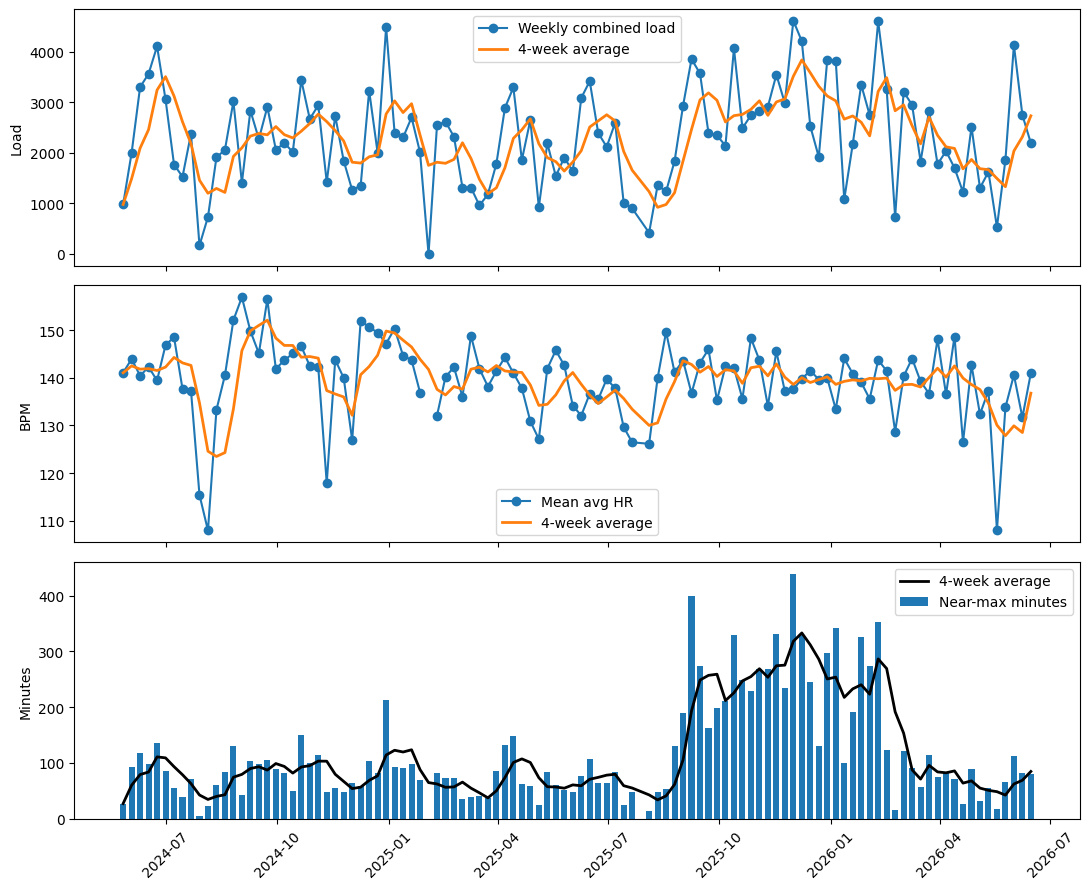

In [ ]:
if plt is None:
    print("matplotlib is not installed, so the visual check is skipped.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

    axes[0].plot(weekly_physio["week_start"], weekly_physio["total_combined_load"], marker="o", label="Weekly combined load")
    axes[0].plot(weekly_physio["week_start"], weekly_physio["load_4w_avg"], linewidth=2, label="4-week average")
    axes[0].set_ylabel("Load")
    axes[0].legend()

    axes[1].plot(weekly_physio["week_start"], weekly_physio["mean_avg_hr"], marker="o", label="Mean avg HR")
    axes[1].plot(weekly_physio["week_start"], weekly_physio["hr_4w_avg"], linewidth=2, label="4-week average")
    axes[1].set_ylabel("BPM")
    axes[1].legend()

    axes[2].bar(weekly_physio["week_start"], weekly_physio["total_near_max_min"], width=5, label="Near-max minutes")
    axes[2].plot(weekly_physio["week_start"], weekly_physio["near_max_4w_avg"], color="black", linewidth=2, label="4-week average")
    axes[2].set_ylabel("Minutes")
    axes[2].legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 10) Save physiology outputs

Prepared physiology tables can feed future notebooks or the web app. This now includes alternate HR zone interpretations so later analysis can compare max-HR, age-aware, HRR, and LTHR-proxy views.

Data flow:

$$
\text{workout HR summaries} \rightarrow \text{workout physiology} \rightarrow \text{weekly physiology}
$$

Code-style implementation:

```python
workouts.to_csv(PROCESSED_DIR / "workout_physiology_metrics.csv", index=False)
weekly_physio.to_csv(PROCESSED_DIR / "weekly_physiology_metrics.csv", index=False)
hr_zone_interpretations.to_csv(PROCESSED_DIR / "hr_zone_interpretations.csv", index=False)
sample_zone_depth.to_csv(PROCESSED_DIR / "hr_sample_zone_depth.csv", index=False)
hr_transition_metrics.to_csv(PROCESSED_DIR / "hr_transition_metrics.csv", index=False)
```

**Expected output:** Expect relationship measures between variables. Interpret direction and strength, but remember correlation does not prove causation.


In [ ]:
workouts.to_csv(PROCESSED_DIR / "workout_physiology_metrics.csv", index=False)
weekly_physio.to_csv(PROCESSED_DIR / "weekly_physiology_metrics.csv", index=False)
load_hr_correlations.to_csv(PROCESSED_DIR / "load_hr_correlations.csv", index=False)
hr_anchors.to_csv(PROCESSED_DIR / "hr_physiology_anchors.csv", index=False)
hr_zone_interpretations.to_csv(PROCESSED_DIR / "hr_zone_interpretations.csv", index=False)
sample_zone_depth.to_csv(PROCESSED_DIR / "hr_sample_zone_depth.csv", index=False)
hr_transition_metrics.to_csv(PROCESSED_DIR / "hr_transition_metrics.csv", index=False)
hr_zone_method_summary.to_csv(PROCESSED_DIR / "hr_zone_method_summary.csv", index=False)
age_hr_context.to_csv(PROCESSED_DIR / "hr_age_context.csv", index=False)

print("Saved physiology outputs:")
print(PROCESSED_DIR / "workout_physiology_metrics.csv")
print(PROCESSED_DIR / "weekly_physiology_metrics.csv")
print(PROCESSED_DIR / "load_hr_correlations.csv")
print(PROCESSED_DIR / "hr_physiology_anchors.csv")
print(PROCESSED_DIR / "hr_zone_interpretations.csv")
print(PROCESSED_DIR / "hr_sample_zone_depth.csv")
print(PROCESSED_DIR / "hr_transition_metrics.csv")
print(PROCESSED_DIR / "hr_zone_method_summary.csv")
print(PROCESSED_DIR / "hr_age_context.csv")


## Raw HR sample zone distribution using the LTHR proxy

The workout-average HR zone is useful, but it can hide interval structure because rest periods pull the average down. To make the physiology view more honest, this section classifies each raw heart-rate sample by the inferred LTHR ratio and summarizes total minutes in each zone.

Expected output: a six-row table (`Z1` through `Z6`) showing estimated minutes, shares, sample counts, and LTHR-based BPM ranges. This output powers the web app's HR Zone Distribution chart.

Math definition:

$$R_{LTHR} = \frac{HR_{sample}}{LTHR_{proxy}}$$

Code-style implementation:

```python
ratio = bpm / lthr_proxy
```

In [ ]:
import csv
import json
import math
from datetime import datetime
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_dir = PROJECT_ROOT / "data" / "processed"
public_data_dir = PROJECT_ROOT / "app" / "public" / "data"
raw_export_path = public_data_dir / "go-swim-export.json"
if not raw_export_path.exists():
    raw_export_path = PROJECT_ROOT / "data" / "raw" / "go-swim-export.json"

anchors = pd.read_csv(processed_dir / "hr_physiology_anchors.csv")
lthr_proxy = float(anchors.loc[anchors["metric"].eq("lthr_proxy_from_avg_hr_p90"), "value"].iloc[0])

zone_defs = [
    {"zone": "Z1", "label": "Z1 Recovery / low", "low_ratio": 0.00, "high_ratio": 0.85, "color": "#94a3b8"},
    {"zone": "Z2", "label": "Z2 Easy aerobic", "low_ratio": 0.85, "high_ratio": 0.90, "color": "#38bdf8"},
    {"zone": "Z3", "label": "Z3 Moderate", "low_ratio": 0.90, "high_ratio": 0.95, "color": "#22c55e"},
    {"zone": "Z4", "label": "Z4 Threshold approach", "low_ratio": 0.95, "high_ratio": 1.00, "color": "#facc15"},
    {"zone": "Z5", "label": "Z5 Above threshold", "low_ratio": 1.00, "high_ratio": 1.06, "color": "#fb923c"},
    {"zone": "Z6", "label": "Z6 Very high / sprint", "low_ratio": 1.06, "high_ratio": math.inf, "color": "#ef4444"},
]

def parse_export_datetime(value):
    if not value:
        return None
    return datetime.fromisoformat(value.replace("Z", "+00:00"))

with raw_export_path.open(encoding="utf-8") as f:
    export_payload = json.load(f)

totals = {zone["zone"]: 0.0 for zone in zone_defs}
sample_counts = {zone["zone"]: 0 for zone in zone_defs}
workouts_used = 0
samples_used = 0
observed_max_bpm = 0.0

for workout in export_payload.get("workouts", []):
    samples = []
    for sample in workout.get("heartRateSamples", []):
        bpm = sample.get("bpm")
        timestamp = parse_export_datetime(sample.get("date") or sample.get("endDate"))
        if isinstance(bpm, (int, float)) and math.isfinite(bpm) and timestamp:
            samples.append((timestamp, float(bpm)))
    if not samples:
        continue
    workouts_used += 1
    samples.sort(key=lambda item: item[0])
    for index, (timestamp, bpm) in enumerate(samples):
        observed_max_bpm = max(observed_max_bpm, bpm)
        if index + 1 < len(samples):
            delta_minutes = (samples[index + 1][0] - timestamp).total_seconds() / 60
            minutes = delta_minutes if 0 < delta_minutes <= 2 else 0.25
        else:
            minutes = 0.25
        ratio = bpm / lthr_proxy
        for zone in zone_defs:
            if zone["low_ratio"] <= ratio < zone["high_ratio"]:
                totals[zone["zone"]] += minutes
                sample_counts[zone["zone"]] += 1
                break
        samples_used += 1

total_minutes = sum(totals.values())
hr_zone_distribution = pd.DataFrame([
    {
        "zone": zone["zone"],
        "label": zone["label"],
        "low_ratio": zone["low_ratio"],
        "high_ratio": "" if not math.isfinite(zone["high_ratio"]) else zone["high_ratio"],
        "low_bpm": round(zone["low_ratio"] * lthr_proxy, 1),
        "high_bpm": "" if not math.isfinite(zone["high_ratio"]) else round(zone["high_ratio"] * lthr_proxy, 1),
        "minutes": round(totals[zone["zone"]], 2),
        "share": round(totals[zone["zone"]] / total_minutes, 6) if total_minutes else 0,
        "sample_count": sample_counts[zone["zone"]],
        "lthr_proxy_bpm": round(lthr_proxy, 3),
        "workouts_used": workouts_used,
        "samples_used": samples_used,
        "observed_max_bpm": round(observed_max_bpm, 1),
        "color": zone["color"],
        "source": "go-swim-export.json heartRateSamples",
    }
    for zone in zone_defs
])

hr_zone_distribution.to_csv(processed_dir / "hr_zone_distribution.csv", index=False)
hr_zone_distribution.to_csv(public_data_dir / "hr_zone_distribution.csv", index=False)

display(hr_zone_distribution.head(3))
display(hr_zone_distribution.tail(3))

,zone,label,low_ratio,high_ratio,low_bpm,high_bpm,minutes,share,sample_count,lthr_proxy_bpm,workouts_used,samples_used,observed_max_bpm,color,source
0,Z1,Z1 Recovery / low,0.00,0.85,0.0,129.9,14855.55,0.346449,156458,152.853,480,452715,208.0,#94a3b8,go-swim-export.json heartRateSamples
1,Z2,Z2 Easy aerobic,0.85,0.9,129.9,137.6,4496.90,0.104873,45193,152.853,480,452715,208.0,#38bdf8,go-swim-export.json heartRateSamples
2,Z3,Z3 Moderate,0.90,0.95,137.6,145.2,4368.55,0.101880,45314,152.853,480,452715,208.0,#22c55e,go-swim-export.json heartRateSamples


,zone,label,low_ratio,high_ratio,low_bpm,high_bpm,minutes,share,sample_count,lthr_proxy_bpm,workouts_used,samples_used,observed_max_bpm,color,source
3,Z4,Z4 Threshold approach,0.95,1.0,145.2,152.9,3840.73,0.089570,39261,152.853,480,452715,208.0,#facc15,go-swim-export.json heartRateSamples
4,Z5,Z5 Above threshold,1.00,1.06,152.9,162.0,6036.68,0.140783,62389,152.853,480,452715,208.0,#fb923c,go-swim-export.json heartRateSamples
5,Z6,Z6 Very high / sprint,1.06,,162.0,,9281.03,0.216445,104100,152.853,480,452715,208.0,#ef4444,go-swim-export.json heartRateSamples
